# Generate all csv files only

In [36]:
import os
import subprocess
import glob
import pandas as pd
import matplotlib.pyplot as plt
import re
import filecmp
workload_dir = './workload'
csv_dir = './csv'

print("Deleted existing CSV files.")
# Clean up old CSV files in workload and csv directories
for f in glob.glob(os.path.join(csv_dir, '*.csv')):
    os.remove(f)

# Run gen_data.py to generate data.csv
print("Running gen_data.py...")
subprocess.run([
    'python3', './gen_py/gen_data.py',
    '-o', os.path.join(csv_dir, 'data.csv'),
    '-n', '100000', '-k', '100', '-p', '100', '-vmin', '800', '-vmax', '800', '-s', '512'
], check=True)
print("data.csv generated.")

# Generate workloads (txs and ops files)
print("Generating workloads...")
subprocess.run(['python3', './gen_py/gen_workloads.py'], check=True)
print("Workloads generated.")

# Generate data after ops for each workload (producing workload-specific *_recent_data_ops_after.csv and *_history_data_ops_after.csv)
print("Generating data after ops for each workload (via gen_workloads_results.py)...")
subprocess.run(['python3', './gen_py/gen_workloads_results.py'], check=True)
print("Workloads results generated.")

Deleted existing CSV files.
Running gen_data.py...
data.csv generated.
Generating workloads...
Generated 2000 transactions in csv/read_only_txs.csv
Generated mixed operations in csv/read_only_ops.csv
Generated 2000 transactions in csv/update_only_txs.csv
Generated mixed operations in csv/update_only_ops.csv
Generated 2000 transactions in csv/insert_only_txs.csv
Generated mixed operations in csv/insert_only_ops.csv
Generated 2000 transactions in csv/insert20_update60_delete20_txs.csv
Generated mixed operations in csv/insert20_update60_delete20_ops.csv
Generated 2000 transactions in csv/read50_insert_50_txs.csv
Generated mixed operations in csv/read50_insert_50_ops.csv
Workloads generated.
Generating data after ops for each workload (via gen_workloads_results.py)...
Processing workload insert20_update60_delete20 with gen_data_after_txs.py...

Processing transactions (txs.csv)...
Generated recent data in csv/insert20_update60_delete20_recent_data_txs_after.csv
Generated history data in cs

Building hash_join_bench with cargo build --release...
Build completed.
Running type chain benchmark for workload insert20_update60_delete20, run 1...


    Finished `release` profile [optimized + debuginfo] target(s) in 0.05s


Running type open_address benchmark for workload insert20_update60_delete20, run 1...
Running type heap benchmark for workload insert20_update60_delete20, run 1...
Running type rust benchmark for workload insert20_update60_delete20, run 1...
Running type chain benchmark for workload insert_only, run 1...
Running type open_address benchmark for workload insert_only, run 1...
Running type heap benchmark for workload insert_only, run 1...
Running type rust benchmark for workload insert_only, run 1...
Running type chain benchmark for workload read50_insert_50, run 1...
Running type open_address benchmark for workload read50_insert_50, run 1...
Running type heap benchmark for workload read50_insert_50, run 1...
Running type rust benchmark for workload read50_insert_50, run 1...
Running type chain benchmark for workload read_only, run 1...
Running type open_address benchmark for workload read_only, run 1...
Running type heap benchmark for workload read_only, run 1...
Running type rust benchm

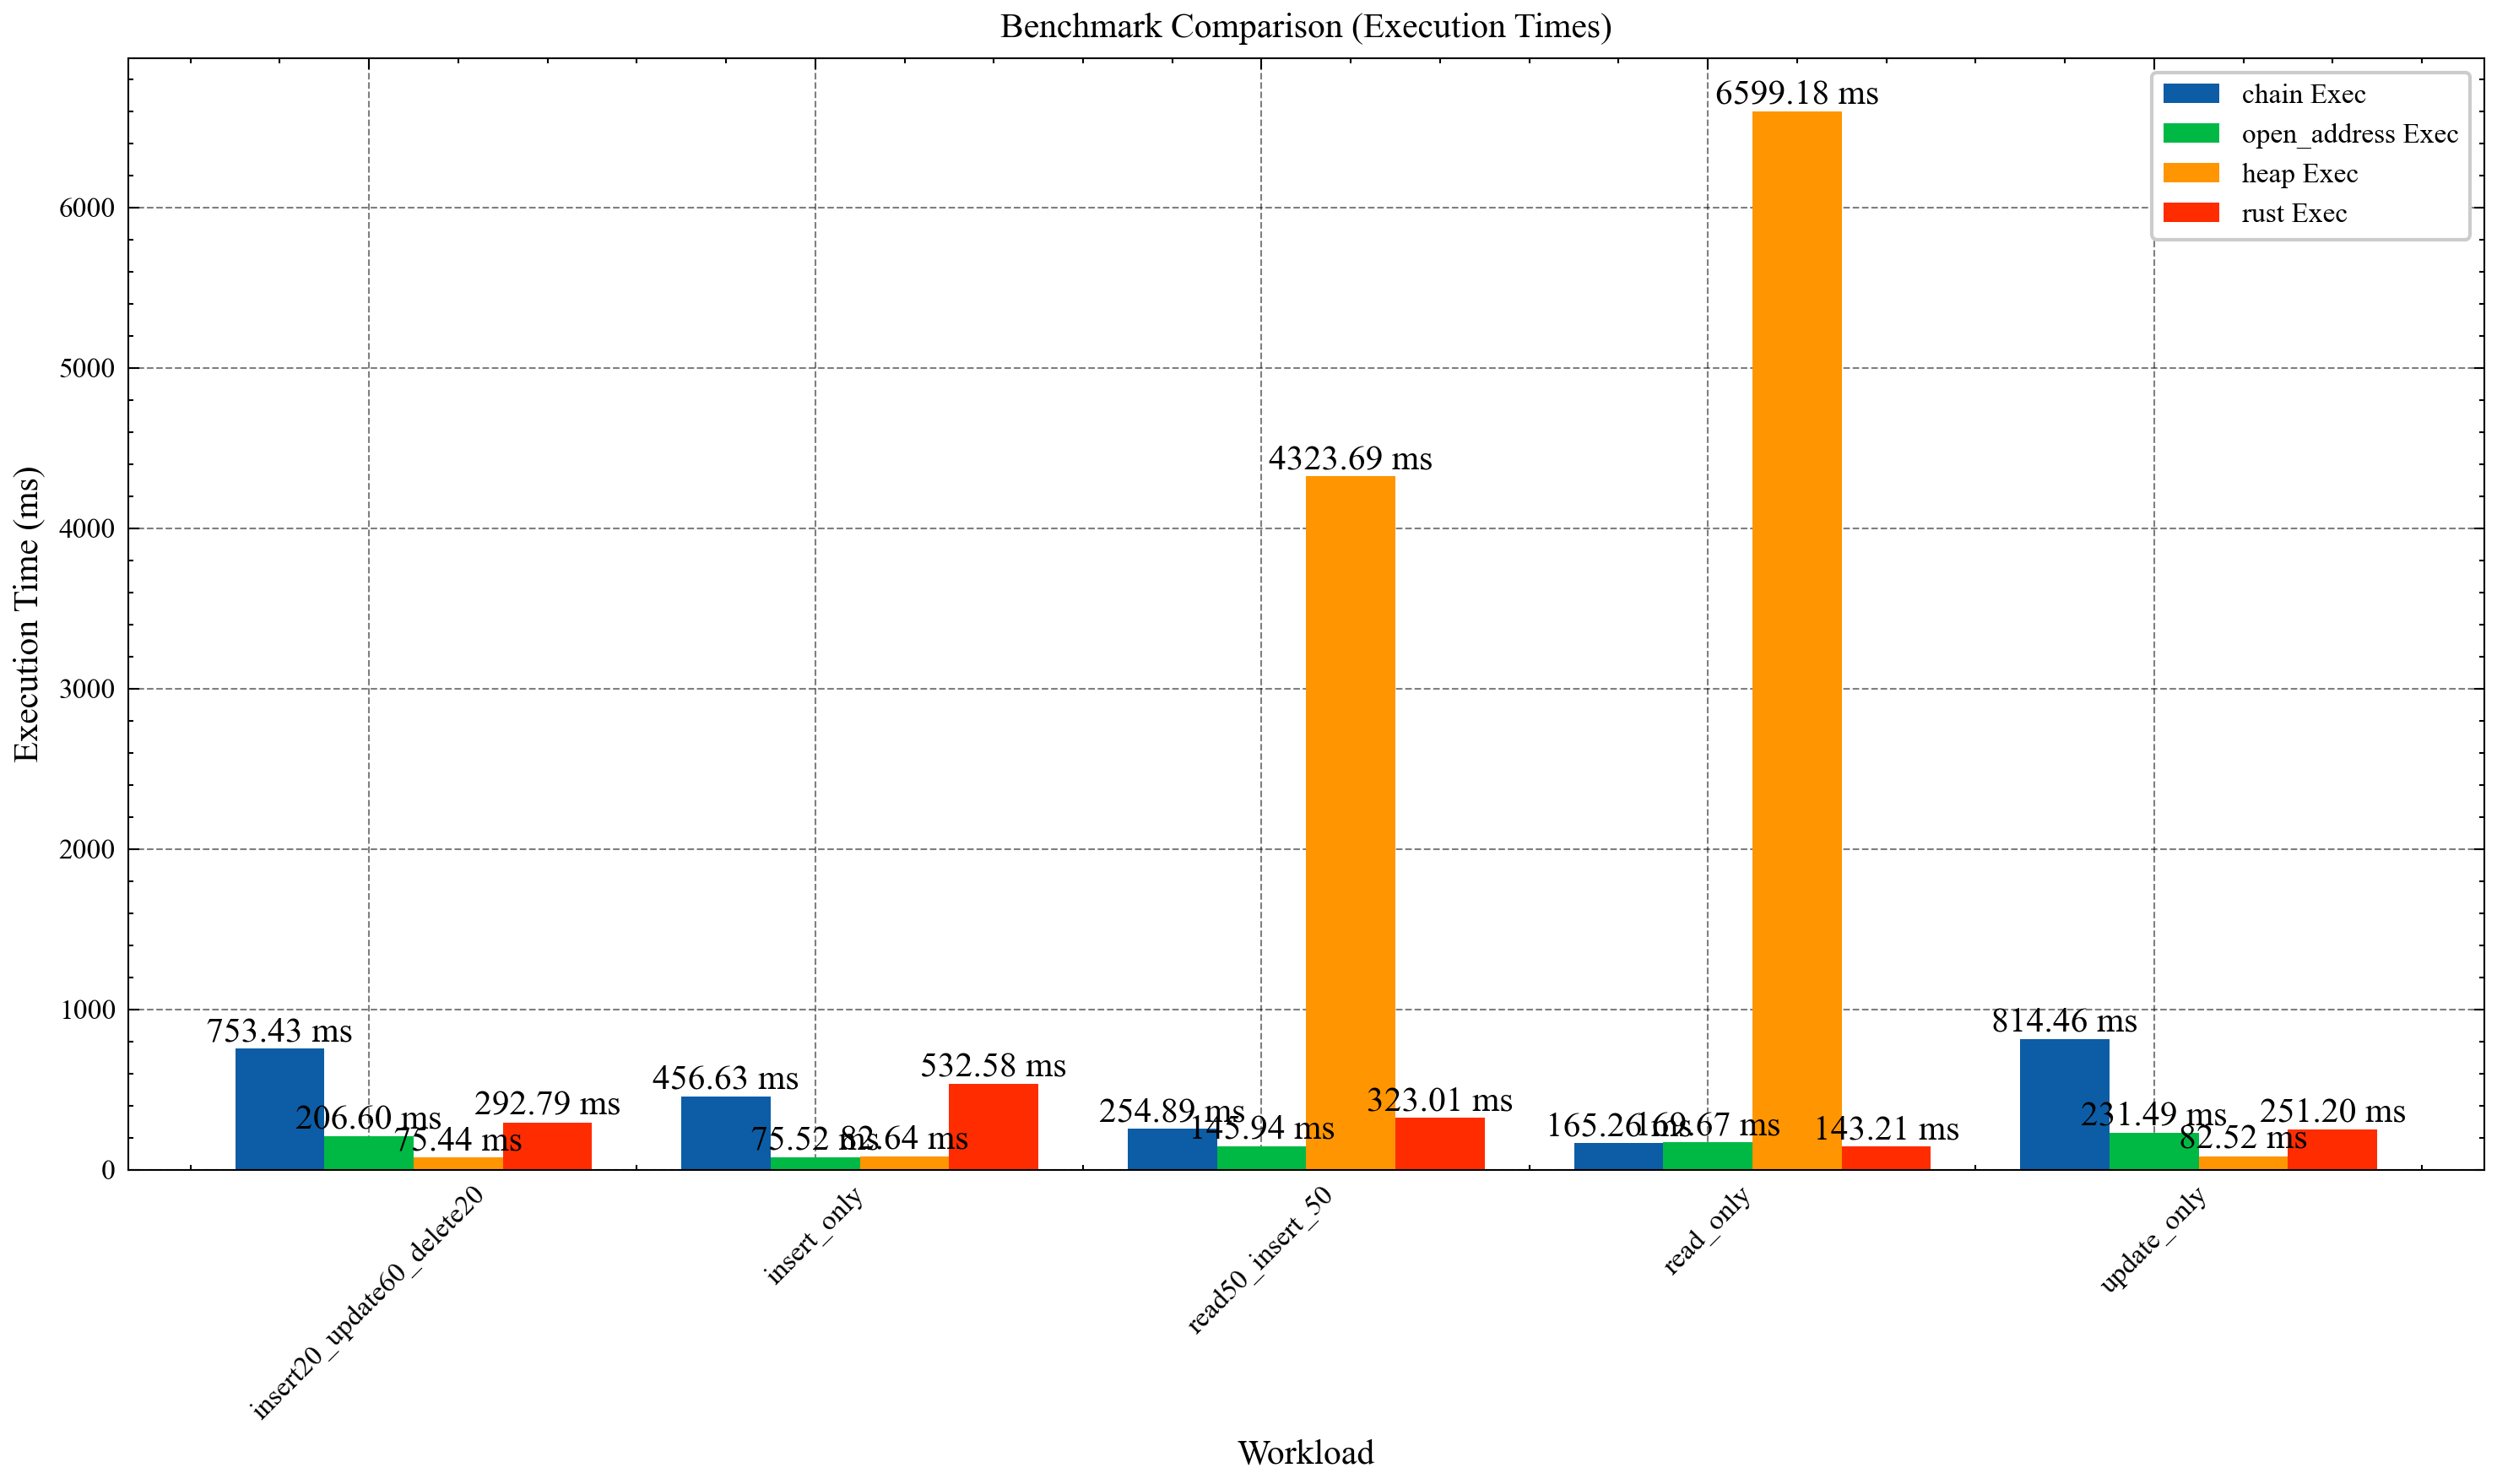

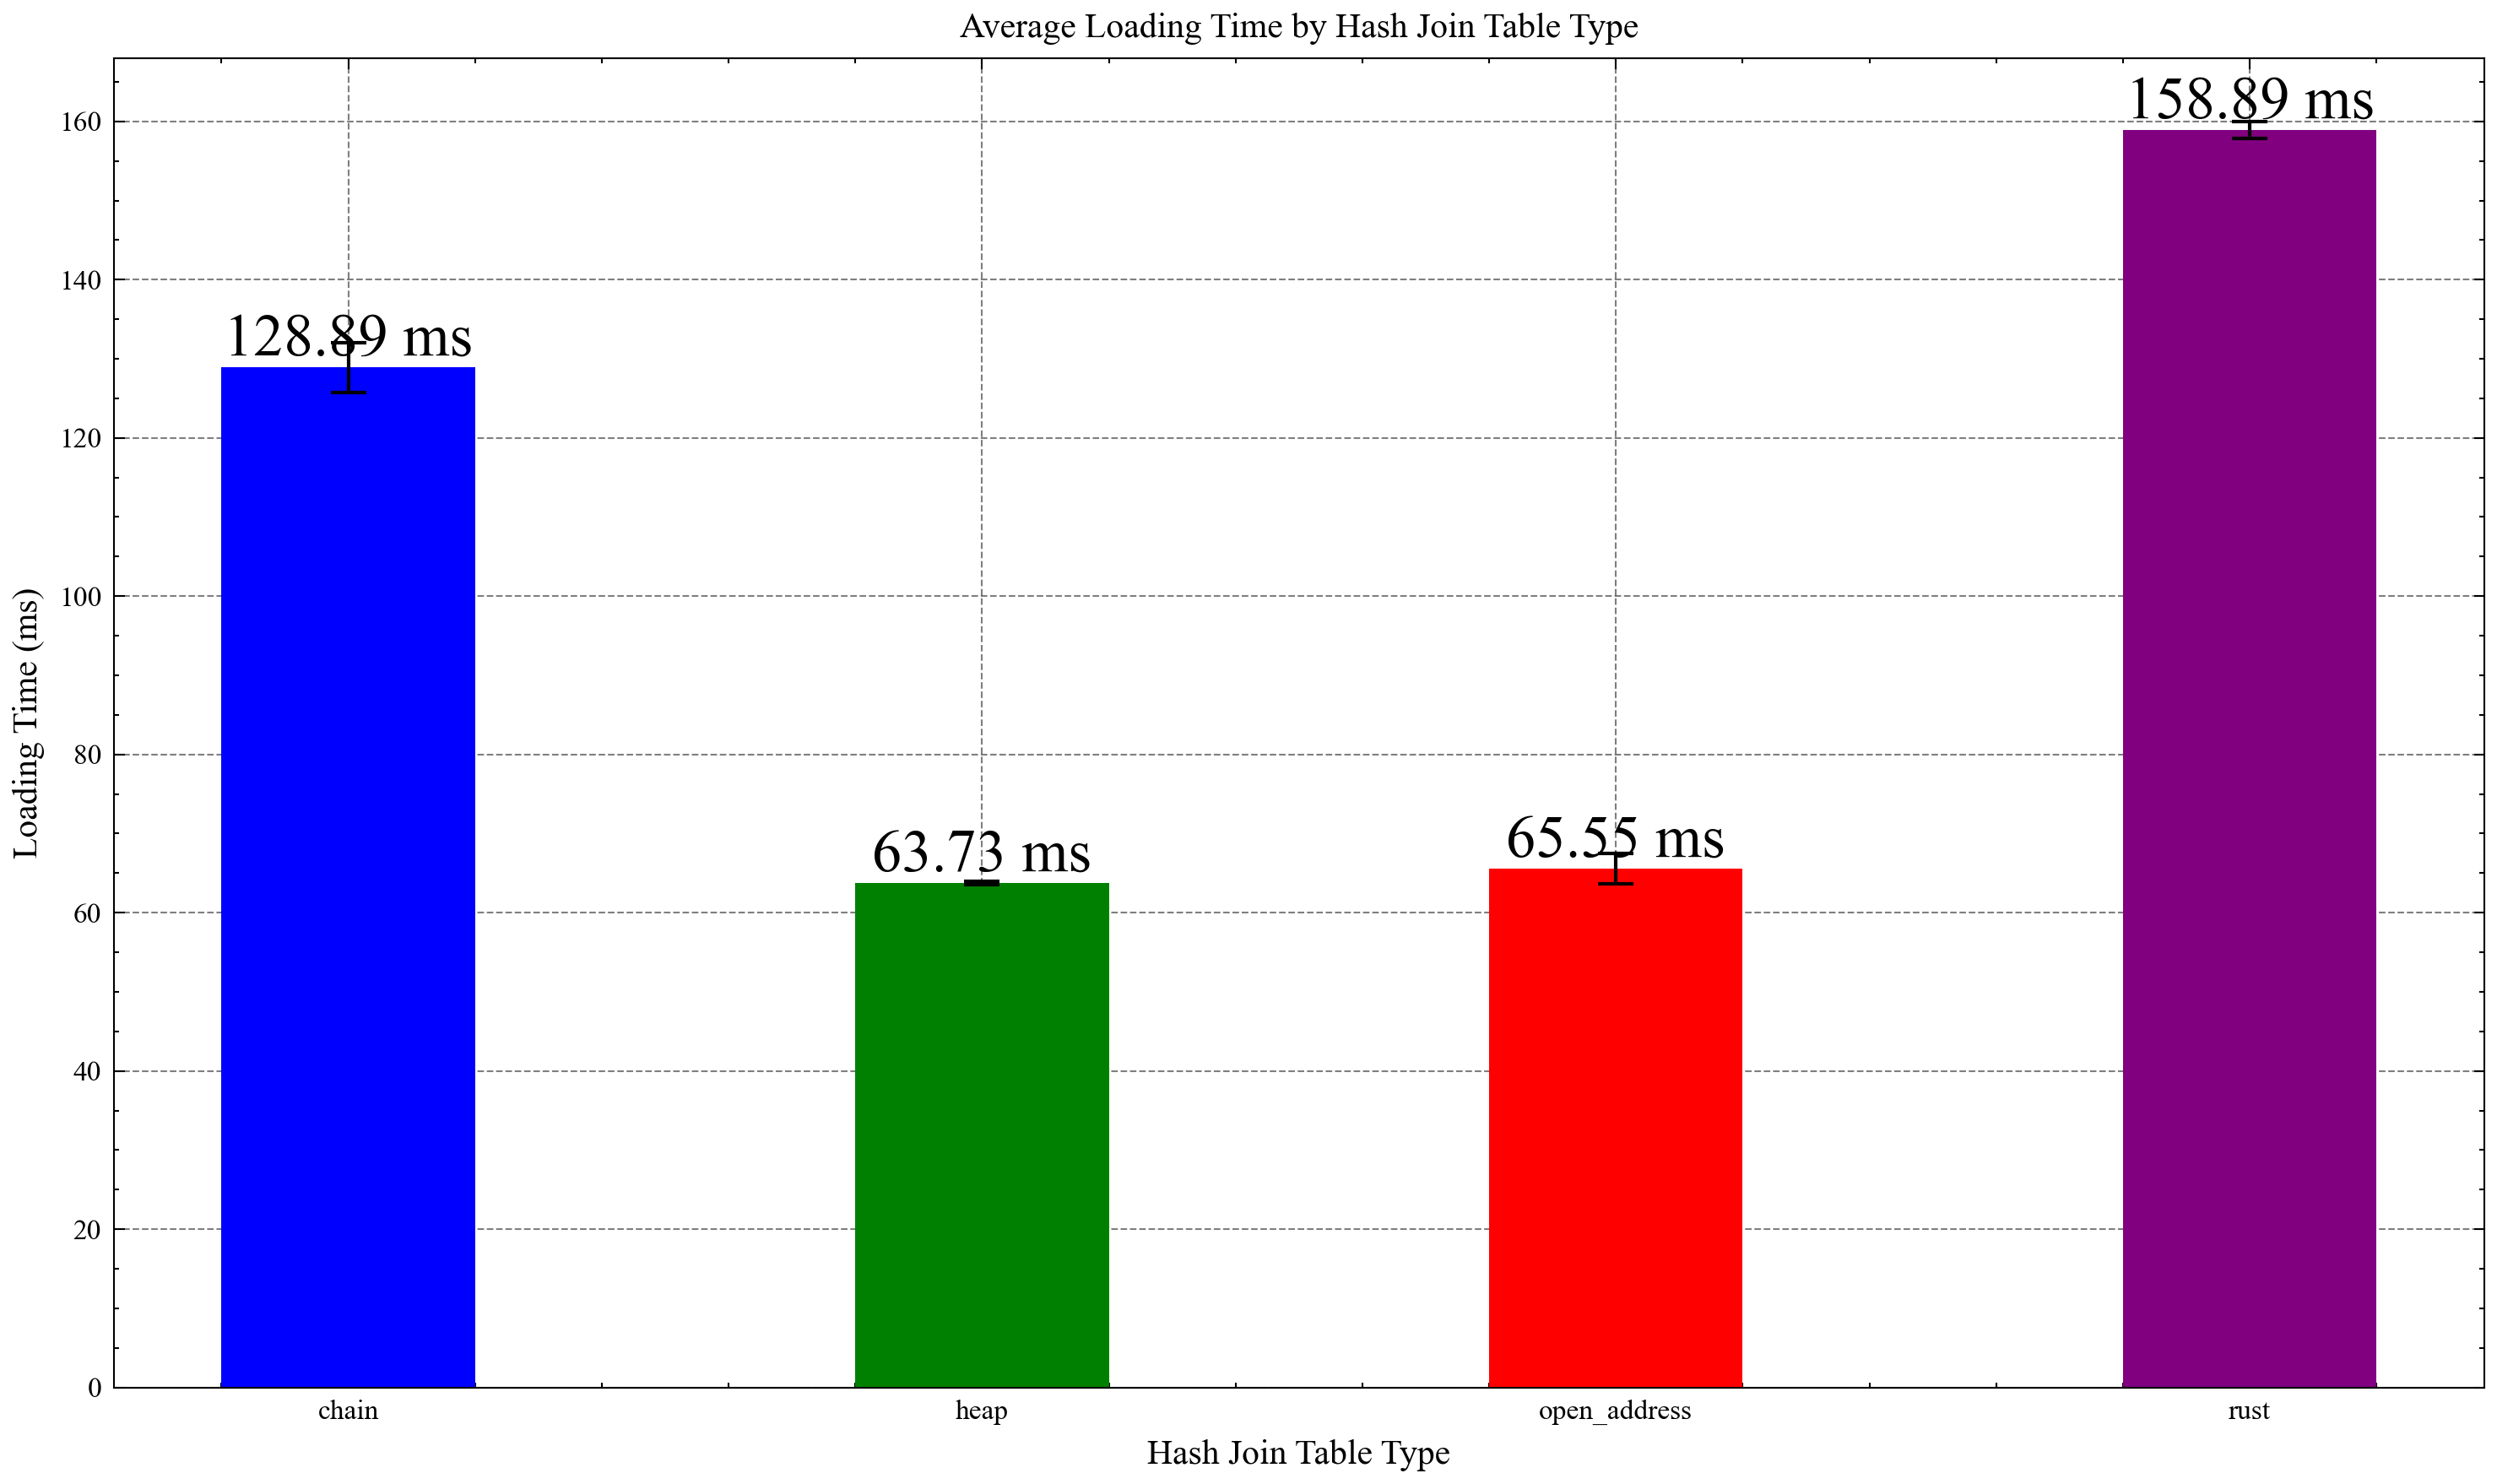

In [ ]:
import os
import subprocess
import glob
import pandas as pd
import matplotlib.pyplot as plt
import re
import filecmp

# Use the custom style
plt.style.use('custom_plt_sytle.mplstyle')

# Number of runs per workload
n = 1

workload_dir = './workload'
csv_dir = './csv'



# Build the binary to ensure it's up-to-date
myenv = os.environ.copy()
myenv["RUSTFLAGS"] = "-Awarnings"
print("Building hash_join_bench with cargo build --release...")
subprocess.run(['cargo', 'build', '--release', '--bin', 'hash_join_bench'], check=True, env=myenv)
print("Build completed.")

binary = '../../target/release/hash_join_bench'
data_file = os.path.join(csv_dir, 'data.csv')
scan_ops_file = os.path.join(csv_dir, 'scan_ops.csv')

# Find all workload ops files in csv directory
ops_files = glob.glob(os.path.join(csv_dir, '*_ops.csv'))
ops_files.sort()

results = []  # will hold dicts of {workload, run, rust_load_ns, hj_load_ns, rust_exec_ns, hj_exec_ns}
hash_join_table_type_list = ["chain", "open_address", "heap", "rust"]
for ops_path in ops_files:
    workload_name = os.path.splitext(os.path.basename(ops_path))[0].replace('_ops','')

    # Corresponding recent/history after ops files
    recent_data_after_ops_file = os.path.join(csv_dir, f'{workload_name}_recent_data_ops_after.csv')
    history_data_after_ops_file = os.path.join(csv_dir, f'{workload_name}_history_data_ops_after.csv')

    # Check if they exist
    if not os.path.exists(recent_data_after_ops_file) or not os.path.exists(history_data_after_ops_file):
        print(f"Missing recent/history after ops files for workload {workload_name}, skipping benchmark.")
        continue

    # Run the benchmark multiple times for each workload
    for run_id in range(1, n+1):
        for hash_join_table_type in hash_join_table_type_list:
            print(f"Running type {hash_join_table_type} benchmark for workload {workload_name}, run {run_id}...")
            cmd = [
                binary,
                '-df', data_file,
                '-of', ops_path,
                '-rdf', recent_data_after_ops_file,
                '-hdf', history_data_after_ops_file,
                '-sof', scan_ops_file,
                '-t', hash_join_table_type
            ]

            completed = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
            if completed.returncode != 0:
                print(f"Benchmark failed for workload {workload_name}, run {run_id}:")
                print(completed.stderr)
                continue

            output = completed.stdout

            # Parse times
            hj_load_time_ns = None
            hj_execute_time_ns = None

            for line in output.splitlines():
                if line.startswith("Loaded") and "HashJoinTable" in line:
                    m = re.search(r'Loaded \d+ entries into HashJoinTable in (\d+) ns', line)
                    if m:
                        hj_load_time_ns = int(m.group(1))
                elif line.startswith("HashJoinTable: Executed"):
                    m = re.search(r'Executed \d+ operations in (\d+) ns', line)
                    if m:
                        hj_execute_time_ns = int(m.group(1))

            if hj_execute_time_ns is None or hj_load_time_ns is None:
                print("Warning: Could not parse all times from output for this run:")
                print(output)
            else:
                results.append({
                    'workload': workload_name,
                    'run': run_id,
                    'hash_join_table_type': hash_join_table_type,
                    'hj_load_ns': hj_load_time_ns,
                    'hj_exec_ns': hj_execute_time_ns
                })
        
print("Benchmarking completed.")

df = pd.DataFrame(results)

if df.empty:
    print("No results were parsed. Check the output format or regex patterns.")
else:
    # Compute means and std dev for each workload (both load and exec times)
    stats = df.groupby(['workload', 'hash_join_table_type']).agg({
        'hj_load_ns': ['mean', 'std'],
        'hj_exec_ns': ['mean', 'std']
    })

    # Flatten column MultiIndex
    stats.columns = [
        'hj_load_mean', 'hj_load_std',
        'hj_exec_mean', 'hj_exec_std'
    ]
    stats = stats.reset_index()

    # Sort workloads alphabetically
    stats = stats.sort_values(['workload', 'hash_join_table_type'])

    # Convert to ms for readability
    stats['hj_load_mean_ms'] = stats['hj_load_mean'] / 1_000_000
    stats['hj_exec_mean_ms'] = stats['hj_exec_mean'] / 1_000_000

    # Print exact numbers
    print("Averaged Results:")
    for i, row in stats.iterrows():
        print(f"Workload: {row['workload']}, HashJoinTable Type: {row['hash_join_table_type']}")
        print(f"  MvccHashJoinTable: load={row['hj_load_mean_ms']:.2f} ms, exec={row['hj_exec_mean_ms']:.2f} ms")

    # Plot Execution Times Comparison
    plt.figure(figsize=(10,6))
    X = range(len(stats))
    bar_width = 0.2
    index = range(len(stats['workload'].unique()))
    index = [x * bar_width * 5 for x in index]

    for i, hash_join_table_type in enumerate(hash_join_table_type_list):
        subset = stats[stats['hash_join_table_type'] == hash_join_table_type]
        bars = plt.bar([x + i * bar_width for x in index], subset['hj_exec_mean_ms'], bar_width, yerr=subset['hj_exec_std']/1_000_000, label=f'{hash_join_table_type} Exec', rotation=45)

        # Annotate bars with exact values
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f} ms", ha='center', va='bottom', fontsize=10, color='black')
    plt.xticks([x + bar_width for x in index], stats['workload'].unique(), rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Execution Time (ms)')
    plt.title('Benchmark Comparison (Execution Times)')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Compute average load times for each hash join table type
    avg_load_times = df.groupby('hash_join_table_type').agg({
        'hj_load_ns': ['mean', 'std']
    }).reset_index()

    avg_load_times.columns = ['hash_join_table_type', 'hj_load_mean', 'hj_load_std']
    avg_load_times['hj_load_mean_ms'] = avg_load_times['hj_load_mean'] / 1_000_000
    avg_load_times['hj_load_std_ms'] = avg_load_times['hj_load_std'] / 1_000_000

    # Plot Loading Times Comparison
    plt.figure(figsize=(10,6))
    colors = ['blue', 'green', 'red', 'purple']
    bars = plt.bar(avg_load_times['hash_join_table_type'], avg_load_times['hj_load_mean_ms'], yerr=avg_load_times['hj_load_std_ms'], capsize=5, width=0.4, color=colors)

    plt.xlabel('Hash Join Table Type')
    plt.ylabel('Loading Time (ms)')
    plt.title('Average Loading Time by Hash Join Table Type')

    # Annotate bars with exact values
    for bar, row in zip(bars, avg_load_times.iterrows()):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f} ms", ha='center', va='bottom', fontsize=17, color='black')

    plt.tight_layout()
    plt.show()


Averaged Results:
Workload: insert20_update60_delete20, HashJoinTable Type: chain
  MvccHashJoinTable: load=130.65 ms, exec=753.43 ms
Workload: insert20_update60_delete20, HashJoinTable Type: heap
  MvccHashJoinTable: load=63.75 ms, exec=75.44 ms
Workload: insert20_update60_delete20, HashJoinTable Type: open_address
  MvccHashJoinTable: load=64.22 ms, exec=206.60 ms
Workload: insert20_update60_delete20, HashJoinTable Type: rust
  MvccHashJoinTable: load=157.42 ms, exec=292.79 ms
Workload: insert_only, HashJoinTable Type: chain
  MvccHashJoinTable: load=133.41 ms, exec=456.63 ms
Workload: insert_only, HashJoinTable Type: heap
  MvccHashJoinTable: load=63.52 ms, exec=82.64 ms
Workload: insert_only, HashJoinTable Type: open_address
  MvccHashJoinTable: load=64.93 ms, exec=75.52 ms
Workload: insert_only, HashJoinTable Type: rust
  MvccHashJoinTable: load=159.66 ms, exec=532.58 ms
Workload: read50_insert_50, HashJoinTable Type: chain
  MvccHashJoinTable: load=126.26 ms, exec=254.89 ms
Workl

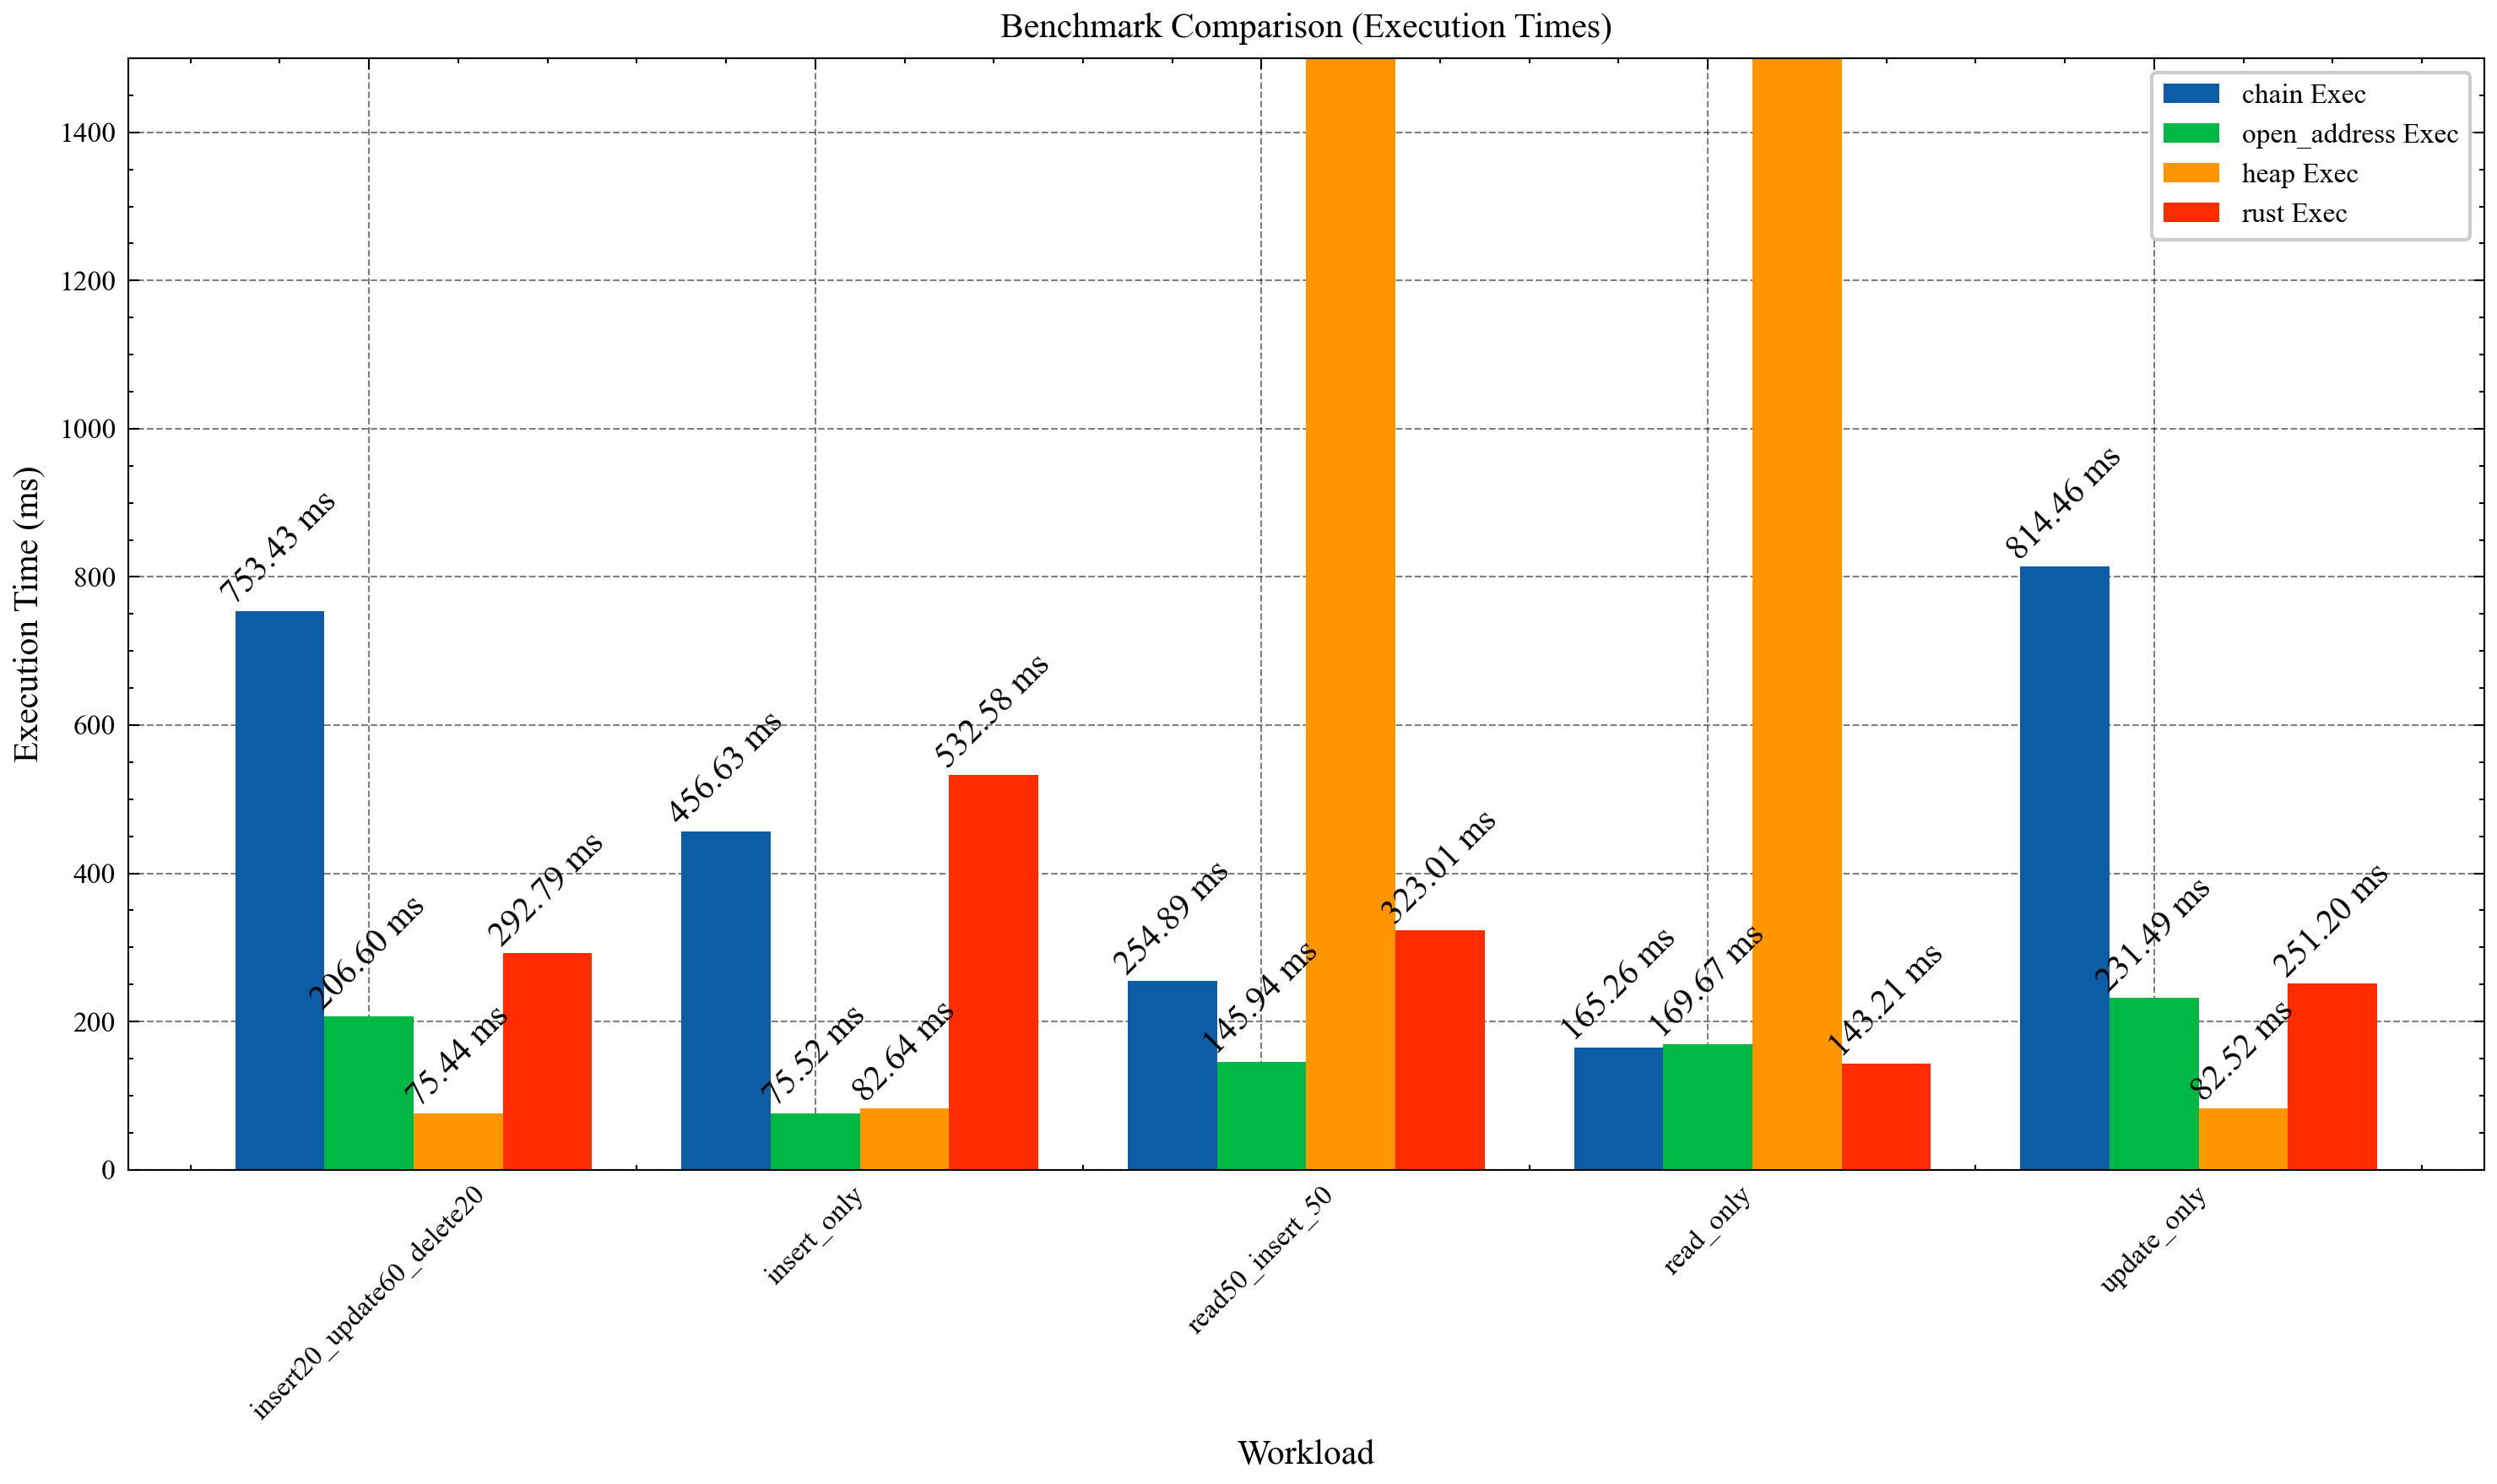

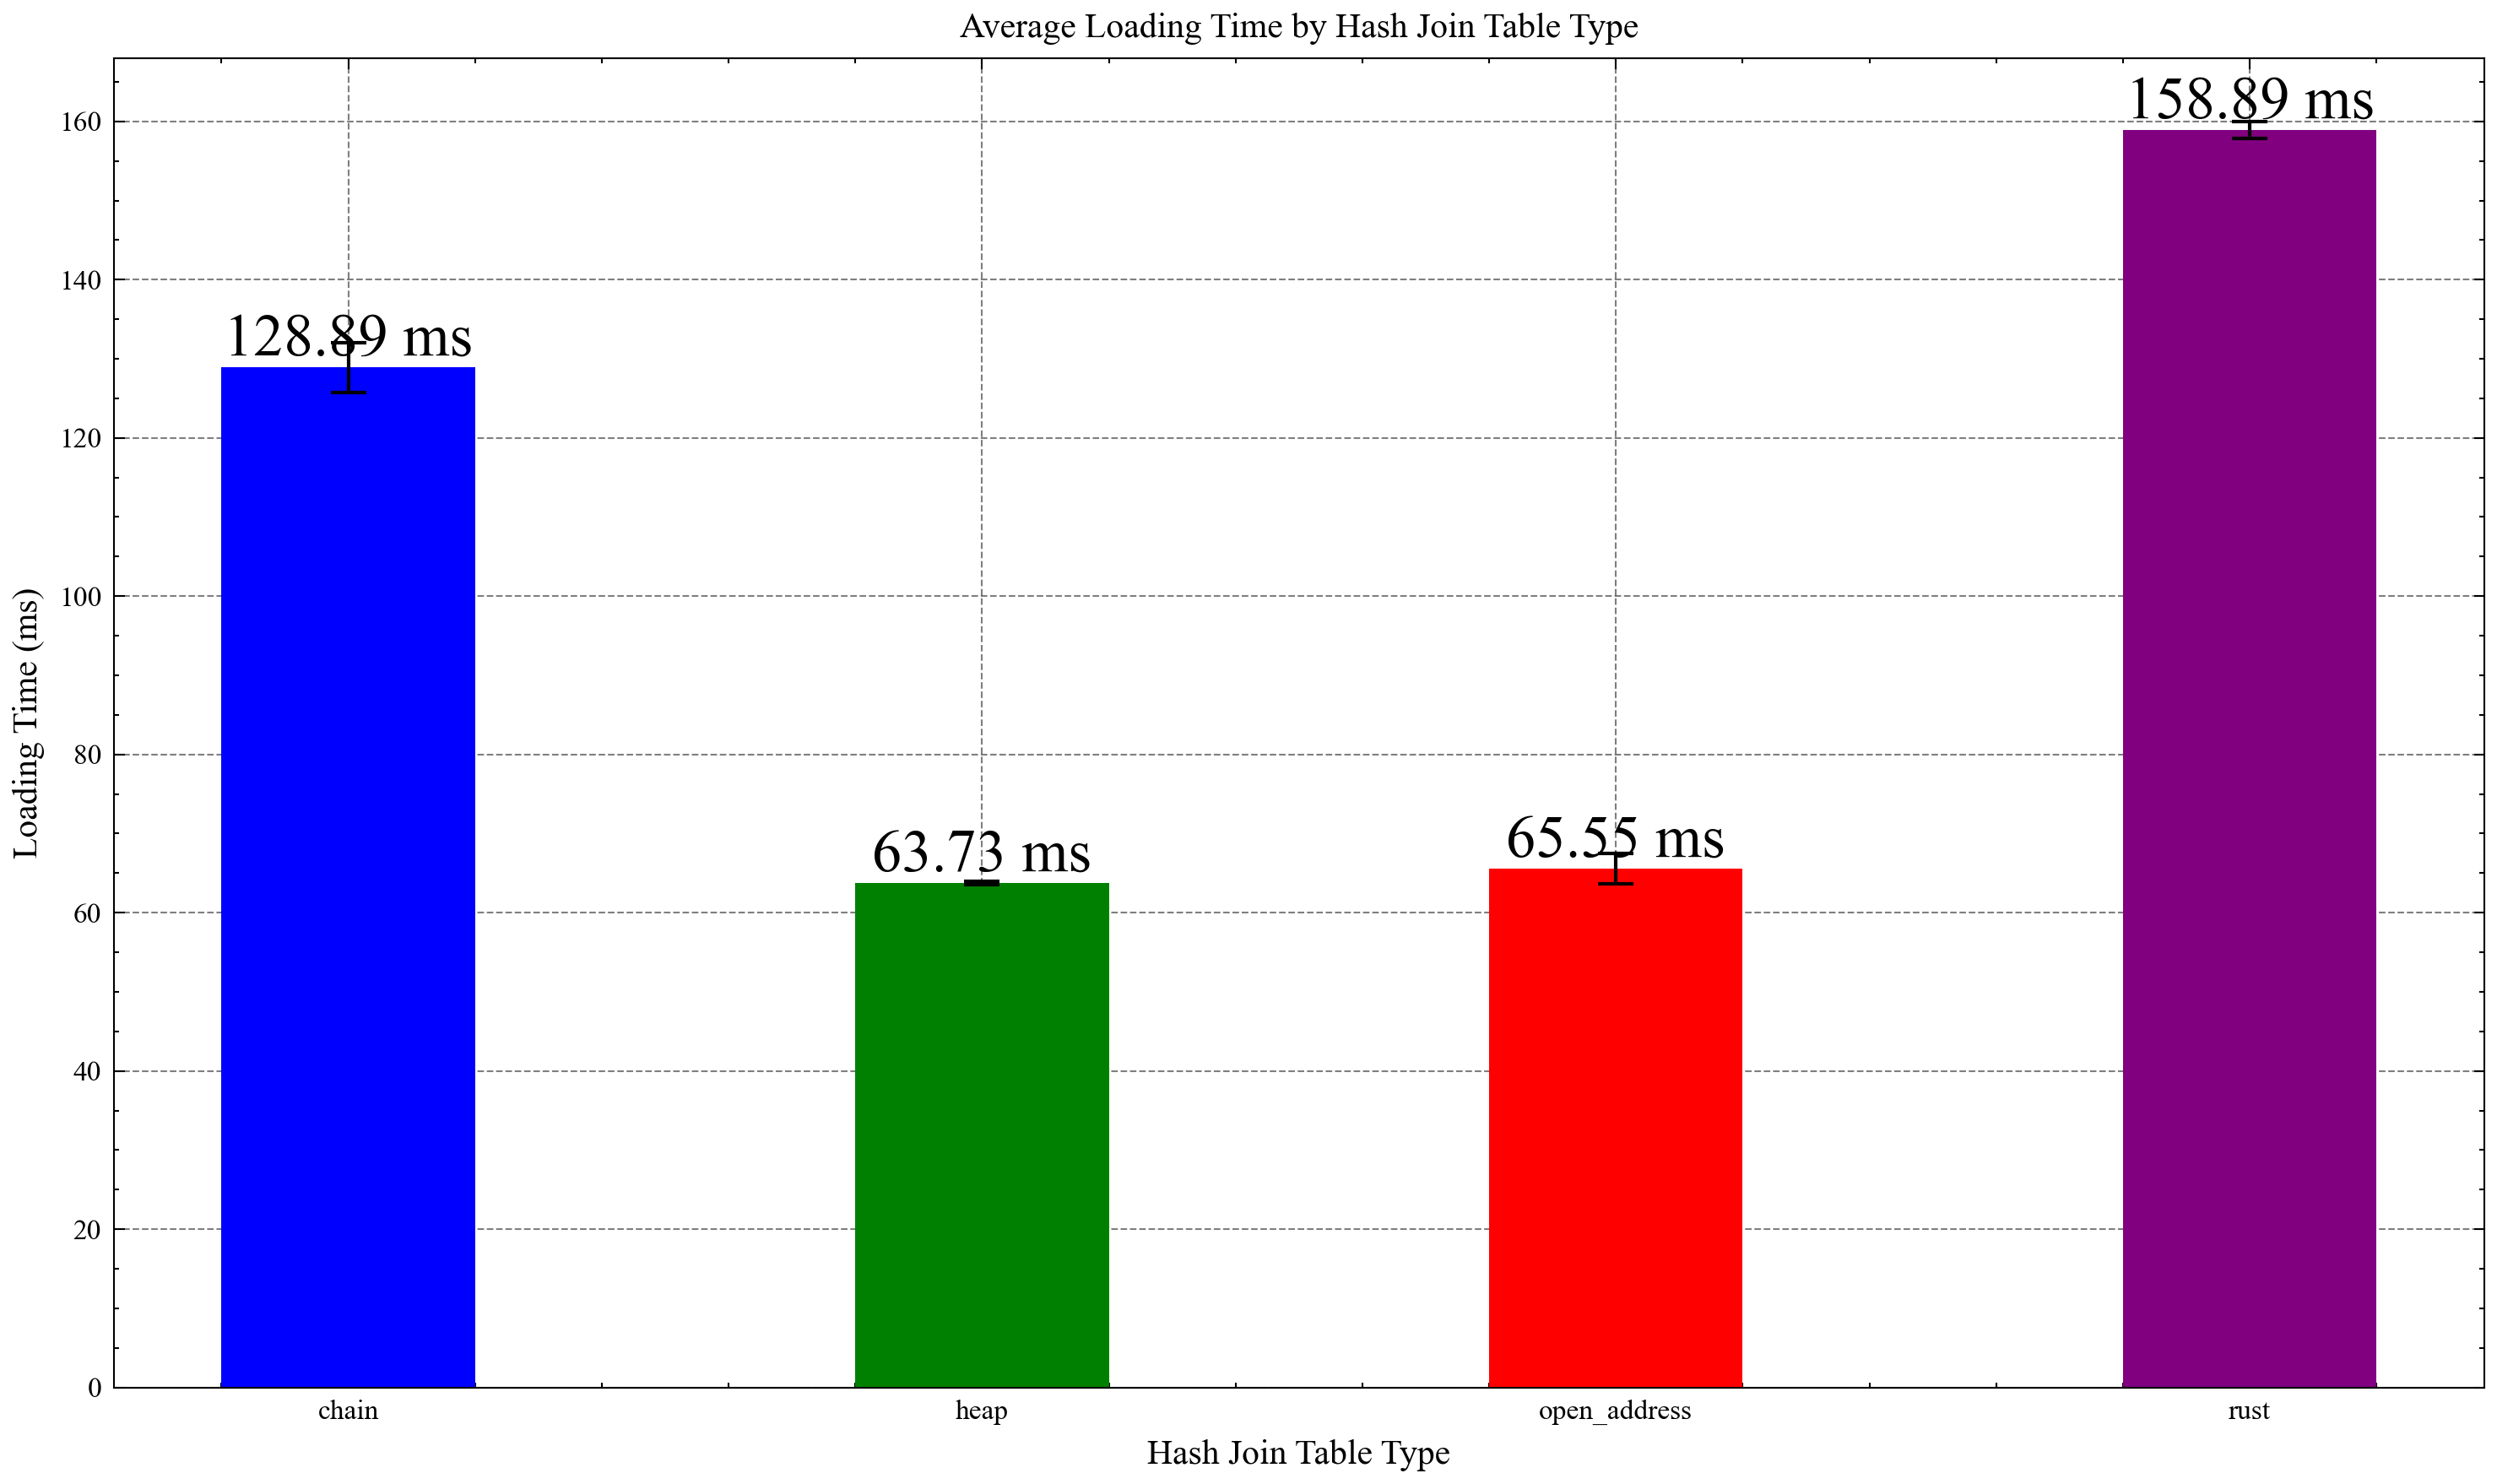

In [41]:
 # Compute means and std dev for each workload (both load and exec times)
stats = df.groupby(['workload', 'hash_join_table_type']).agg({
    'hj_load_ns': ['mean', 'std'],
    'hj_exec_ns': ['mean', 'std']
})

# Flatten column MultiIndex
stats.columns = [
    'hj_load_mean', 'hj_load_std',
    'hj_exec_mean', 'hj_exec_std'
]
stats = stats.reset_index()

# Sort workloads alphabetically
stats = stats.sort_values(['workload', 'hash_join_table_type'])

# Convert to ms for readability
stats['hj_load_mean_ms'] = stats['hj_load_mean'] / 1_000_000
stats['hj_exec_mean_ms'] = stats['hj_exec_mean'] / 1_000_000

# Print exact numbers
print("Averaged Results:")
for i, row in stats.iterrows():
    print(f"Workload: {row['workload']}, HashJoinTable Type: {row['hash_join_table_type']}")
    print(f"  MvccHashJoinTable: load={row['hj_load_mean_ms']:.2f} ms, exec={row['hj_exec_mean_ms']:.2f} ms")

# Plot Execution Times Comparison
plt.figure(figsize=(10,6))
X = range(len(stats))
bar_width = 0.2
index = range(len(stats['workload'].unique()))
index = [x * bar_width * 5 for x in index]
max_y_range = 1500

for i, hash_join_table_type in enumerate(hash_join_table_type_list):
    subset = stats[stats['hash_join_table_type'] == hash_join_table_type]
    bars = plt.bar([x + i * bar_width for x in index], subset['hj_exec_mean_ms'], bar_width, yerr=subset['hj_exec_std']/1_000_000, label=f'{hash_join_table_type} Exec')

    # Annotate bars with exact values
    for bar in bars:
        height = bar.get_height()
        if height <= max_y_range:
            plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f} ms", ha='center', va='bottom', fontsize=10, color='black', rotation=45)
plt.xticks([x + bar_width for x in index], stats['workload'].unique(), rotation=45)
plt.xlabel('Workload')
plt.ylabel('Execution Time (ms)')
plt.title('Benchmark Comparison (Execution Times)')
plt.legend()
plt.ylim(0, max_y_range)  # Set y-axis range

plt.tight_layout()
plt.show()

# Compute average load times for each hash join table type
avg_load_times = df.groupby('hash_join_table_type').agg({
    'hj_load_ns': ['mean', 'std']
}).reset_index()

avg_load_times.columns = ['hash_join_table_type', 'hj_load_mean', 'hj_load_std']
avg_load_times['hj_load_mean_ms'] = avg_load_times['hj_load_mean'] / 1_000_000
avg_load_times['hj_load_std_ms'] = avg_load_times['hj_load_std'] / 1_000_000

# Plot Loading Times Comparison
plt.figure(figsize=(10,6))
colors = ['blue', 'green', 'red', 'purple']
bars = plt.bar(avg_load_times['hash_join_table_type'], avg_load_times['hj_load_mean_ms'], yerr=avg_load_times['hj_load_std_ms'], capsize=5, width=0.4, color=colors)

plt.xlabel('Hash Join Table Type')
plt.ylabel('Loading Time (ms)')
plt.title('Average Loading Time by Hash Join Table Type')

# Annotate bars with exact values
for bar, row in zip(bars, avg_load_times.iterrows()):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f} ms", ha='center', va='bottom', fontsize=17, color='black')

plt.tight_layout()
plt.show()
